<a href="https://colab.research.google.com/github/ShashikanthKungulwar/DL/blob/main/NN_1st.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn

In [2]:
class Model(nn.Module):
  def __init__(self,n_input_features = 4,out_features = 3):
    super(Model,self).__init__()
    self.nn1 = nn.Linear(4,10)
    self.activation = nn.ReLU()
    self.nn2 = nn.Linear(10,6)
    self.softmax = nn.Softmax()
    self.nn3 = nn.Linear(6,out_features)
  def forward(self,x):
    x = self.nn1(x)
    x = self.activation(x)
    x = self.nn2(x)
    x = self.activation(x)
    x = self.nn3(x)
    x = self.softmax(x)
    return x

In [3]:
torch.manual_seed(41)

In [4]:
model = Model()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
url = "https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv"
df = pd.read_csv(url)

In [8]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [9]:
from sklearn.preprocessing import LabelEncoder

In [10]:
encoder = LabelEncoder()

In [11]:
df["species"] = encoder.fit_transform(df["species"])

In [12]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [14]:
df.species.value_counts()

,count
species,
0,50
1,50
2,50


In [18]:
x = df.drop("species",axis = 1)
y = df["species"]

In [19]:
x = x.values
y = y.values


In [24]:
torch.tensor(x,dtype = torch.float64)

tensor([[5.1000, 3.5000, 1.4000, 0.2000],
        [4.9000, 3.0000, 1.4000, 0.2000],
        [4.7000, 3.2000, 1.3000, 0.2000],
        [4.6000, 3.1000, 1.5000, 0.2000],
        [5.0000, 3.6000, 1.4000, 0.2000],
        [5.4000, 3.9000, 1.7000, 0.4000],
        [4.6000, 3.4000, 1.4000, 0.3000],
        [5.0000, 3.4000, 1.5000, 0.2000],
        [4.4000, 2.9000, 1.4000, 0.2000],
        [4.9000, 3.1000, 1.5000, 0.1000],
        [5.4000, 3.7000, 1.5000, 0.2000],
        [4.8000, 3.4000, 1.6000, 0.2000],
        [4.8000, 3.0000, 1.4000, 0.1000],
        [4.3000, 3.0000, 1.1000, 0.1000],
        [5.8000, 4.0000, 1.2000, 0.2000],
        [5.7000, 4.4000, 1.5000, 0.4000],
        [5.4000, 3.9000, 1.3000, 0.4000],
        [5.1000, 3.5000, 1.4000, 0.3000],
        [5.7000, 3.8000, 1.7000, 0.3000],
        [5.1000, 3.8000, 1.5000, 0.3000],
        [5.4000, 3.4000, 1.7000, 0.2000],
        [5.1000, 3.7000, 1.5000, 0.4000],
        [4.6000, 3.6000, 1.0000, 0.2000],
        [5.1000, 3.3000, 1.7000, 0

In [26]:
x = torch.FloatTensor(x)
y = torch.LongTensor(y)

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 41)

In [30]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [34]:
epochs = 100
losses = []
for i in range(epochs):
  y_pred = model.forward(x_train)

  loss = criterion(y_pred,y_train)
  losses.append(loss)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if(i%10 == 0):
    print(f"Epochs : {i} Loss : {loss}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epochs : 0 Loss : 1.1094157695770264
Epochs : 10 Loss : 1.0961335897445679
Epochs : 20 Loss : 1.083162546157837
Epochs : 30 Loss : 1.0739529132843018
Epochs : 40 Loss : 1.0641676187515259
Epochs : 50 Loss : 1.0531837940216064
Epochs : 60 Loss : 1.0399447679519653
Epochs : 70 Loss : 1.024562954902649
Epochs : 80 Loss : 1.0080392360687256
Epochs : 90 Loss : 0.9895291924476624


In [35]:
model = Model()

In [40]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.01)

In [47]:
print(losses[0])
print(losses[0].item())


tensor(1.1094, grad_fn=<NllLossBackward0>)
1.1094157695770264


In [48]:
epochs = 100
losses = []
model.train()
for i in range(epochs):
  y_pred = model.forward(x_train)

  loss = criterion(y_pred,y_train)
  losses.append(loss.item())

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  if(i%10 == 0):
    print(f"Epochs : {i} Loss : {loss.item()}")


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Epochs : 0 Loss : 1.157758116722107
Epochs : 10 Loss : 1.0599453449249268
Epochs : 20 Loss : 0.9663682579994202
Epochs : 30 Loss : 0.870178759098053
Epochs : 40 Loss : 0.8179650902748108
Epochs : 50 Loss : 0.7833649516105652
Epochs : 60 Loss : 0.7355250716209412
Epochs : 70 Loss : 0.6761801838874817
Epochs : 80 Loss : 0.6252239942550659
Epochs : 90 Loss : 0.5955749750137329


In [38]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.0490, -0.2167, -0.0117,  0.3864],
         [ 0.4380,  0.4169,  0.3308,  0.2745],
         [ 0.4956, -0.4647, -0.4381,  0.2986],
         [ 0.4806, -0.3536,  0.2234, -0.2594],
         [-0.0907,  0.4738, -0.2948,  0.2404],
         [ 0.3668,  0.2421, -0.3412,  0.1535],
         [-0.4516, -0.2578, -0.2904,  0.3402],
         [ 0.1172,  0.4814,  0.3236, -0.1517],
         [ 0.4824, -0.3331, -0.1538, -0.1301],
         [ 0.1995, -0.2146, -0.3972,  0.3065]], requires_grad=True),
 Parameter containing:
 tensor([ 0.4130,  0.3039,  0.2815, -0.1596, -0.1719, -0.4385,  0.0113,  0.3226,
          0.2588,  0.4292], requires_grad=True),
 Parameter containing:
 tensor([[-0.2452, -0.2766,  0.1477,  0.3084, -0.1066,  0.0572,  0.0908,  0.1652,
           0.0470, -0.2714],
         [-0.0557,  0.1636, -0.0148, -0.2289, -0.1983, -0.1041,  0.2361,  0.0506,
           0.2362,  0.0311],
         [ 0.1941,  0.0303,  0.2165,  0.2737, -0.2645, -0.2330, -0.1177, -0.0083,
     

In [62]:
# y_pred = model.forward(x_test)
model.eval()
with torch.no_grad():
  y_pred = model.forward(x_test)
  print(y_pred.shape)
  loss = criterion(y_pred,y_test)
  print(loss)



torch.Size([30, 3])
tensor(0.6082)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [67]:
y_pred = y_pred.argmax(axis = 1)

In [68]:
y_test.shape

torch.Size([30])

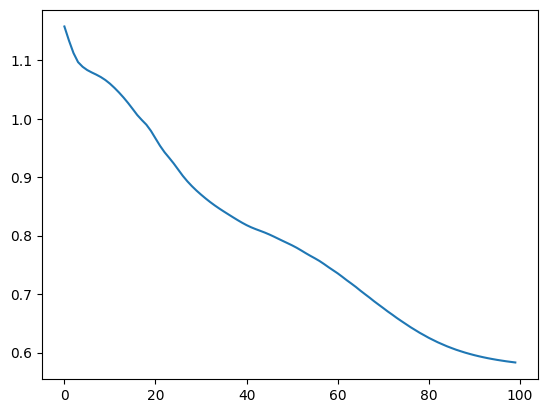

In [56]:
plt.plot(range(epochs),losses)

In [55]:
y_pred[0]

tensor([1.0964e-07, 1.0749e-02, 9.8925e-01], grad_fn=<SelectBackward0>)

In [52]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [75]:
print(accuracy_score(y_test,y_pred)*y_test.shape[0])
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

29.0
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.91      0.95        11
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [78]:
torch.save(model.state_dict(),"model.pt")

In [79]:
new_mode = Model()

In [81]:
with torch.no_grad():
  y_pred_new = new_mode.forward(x_test)
  # print(y_pred_new.shape)
  loss = criterion(y_pred_new,y_test)
  print(loss.item())

1.1090810298919678


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


In [82]:
new_mode.load_state_dict(torch.load("model.pt"))

<All keys matched successfully>

In [83]:
with torch.no_grad():
  y_pred_new = new_mode.forward(x_test)
  # print(y_pred_new.shape)
  loss = criterion(y_pred_new,y_test)
  print(loss.item())

0.6081644892692566


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1775: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)
